# Bounded process (proportions and rates)

Many series live inside fixed bounds — proportions, utilization rates, market shares that must stay in [0, 1]. A bounded process keeps values inside the interval while still allowing autocorrelation and mean reversion, unlike an unbounded random walk that would eventually escape.

::: {.callout-note}
## The model

$$\mu_t = \omega + \phi\, x_{t-1}, \qquad x_t \sim \mathrm{Beta}\!\big(\mu_t \kappa,\, (1-\mu_t)\kappa\big)$$

Pick `model="beta_ar"` (a Beta-distributed autoregression that mean-reverts inside the interval) or `model="logit_normal"` (a random walk in logit space mapped back to (0, 1)). Both guarantee valid bounded output with tunable persistence.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import BoundedProcessGenerator

## 1. Model choice

Both models stay inside the interval, by different routes: `beta_ar` mean-reverts through a conditional Beta draw, while `logit_normal` runs an AR(1) in logit space and maps back. The dashed lines mark the bounds neither can cross.


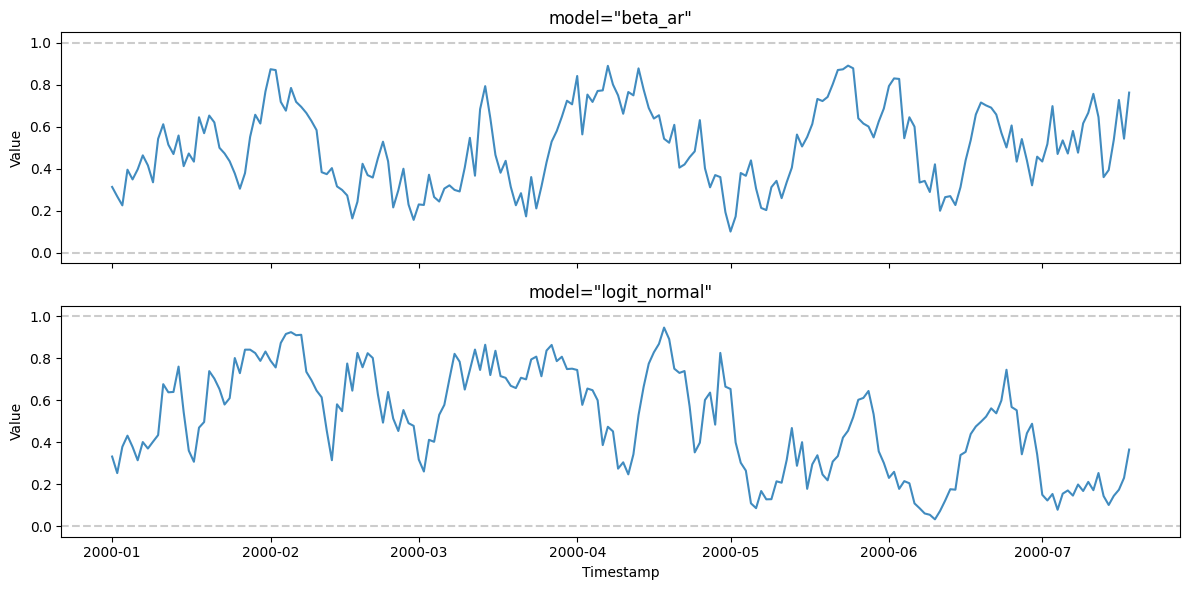

In [ ]:
beta_df = BoundedProcessGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    model="beta_ar",
    phi=0.8,
    omega=0.1,
    kappa=20.0,
    seed=42,
).generate(n_series=1)

logit_df = BoundedProcessGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    model="logit_normal",
    phi=0.9,
    sigma=0.5,
    seed=42,
).generate(n_series=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
panels = [("beta_ar", beta_df), ("logit_normal", logit_df)]
for ax, (label, df) in zip(axes, panels):
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.85)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
    ax.axhline(1, color="gray", linestyle="--", alpha=0.4)
    ax.set(ylim=(-0.05, 1.05), ylabel="Value", title=f'model="{label}"')
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## 2. Custom bounds

Scale the output to any `[lower, upper]` interval, e.g., temperature in [15, 35].

Min=21.01, Max=34.23


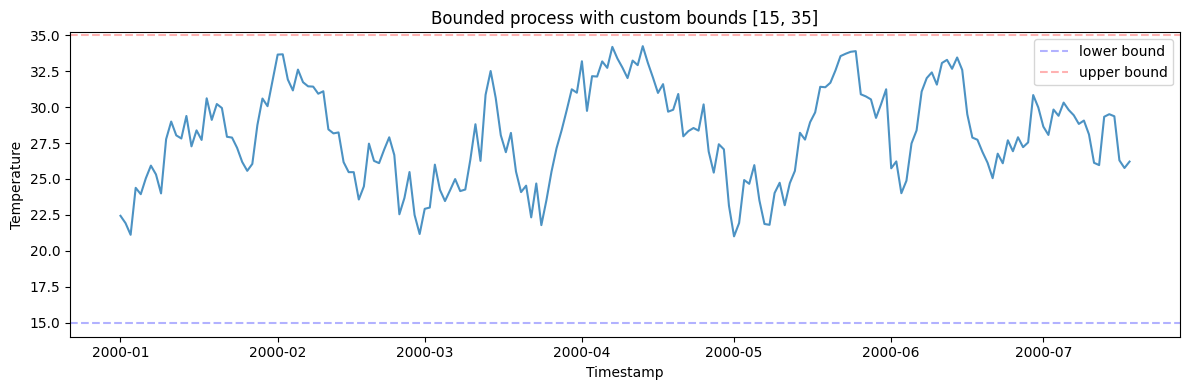

In [ ]:
temp_gen = BoundedProcessGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    model="beta_ar",
    phi=0.85,
    omega=0.1,
    kappa=30.0,
    lower=15.0,
    upper=35.0,
    seed=42,
)
temp_df = temp_gen.generate(n_series=1)

print(f"Min={temp_df['y'].min():.2f}, Max={temp_df['y'].max():.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(temp_df["ds"].to_list(), temp_df["y"].to_list(), alpha=0.8)
ax.axhline(y=15, color="blue", linestyle="--", alpha=0.3, label="lower bound")
ax.axhline(y=35, color="red", linestyle="--", alpha=0.3, label="upper bound")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature")
ax.set_title("Bounded process with custom bounds [15, 35]")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Multiple series

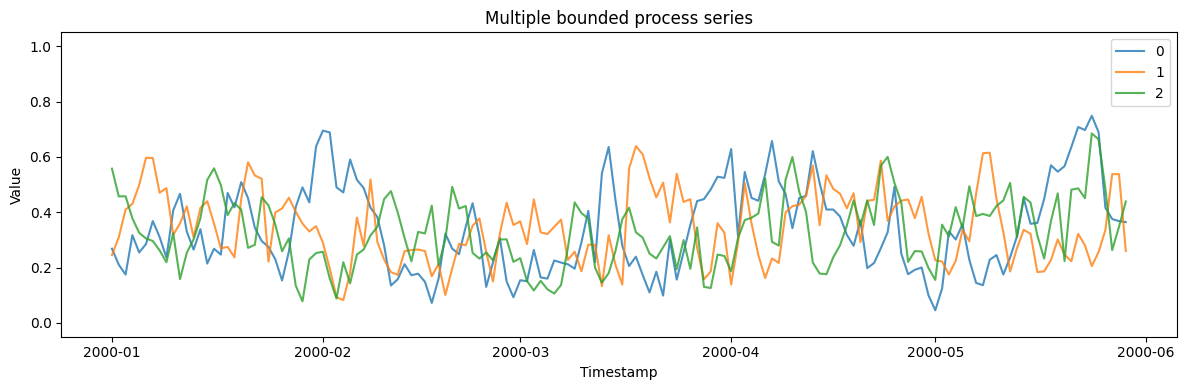

In [ ]:
multi_gen = BoundedProcessGenerator(engine="polars", 
    min_length=150, max_length=150, freq="D",
    model="beta_ar", phi=0.7, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple bounded process series")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Ornstein-Uhlenbeck](/synforecast/docs/generators/stochastic/ornstein_uhlenbeck.html) — unbounded mean reversion.
- [INAR](/synforecast/docs/generators/statistical/inar.html) — bounded-below integer counts.

Model choices and parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::